In [1]:
def moving_average(values, window):
    return np.convolve(values, np.ones(window)/window, mode='valid')


def exponential_moving_average(values, smoothing_factor=0.9):
    smoothed = []
    last = values[0]
    for v in values:
        smoothed_val = last * smoothing_factor + (1 - smoothing_factor) * v
        smoothed.append(smoothed_val)
        last = smoothed_val
    return np.array(smoothed)

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
from scipy.stats import sem

In [3]:
# Set Times New Roman globally if installed
# plt.rcParams["font.family"] = "Times New Roman"
# plt.rcParams["font.size"] = 12

# plt.rcParams['text.usetex'] = True

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{mathptmx}"  # Times-like serif font
})

In [4]:
Training  = "2025-07-24_10-04-42"

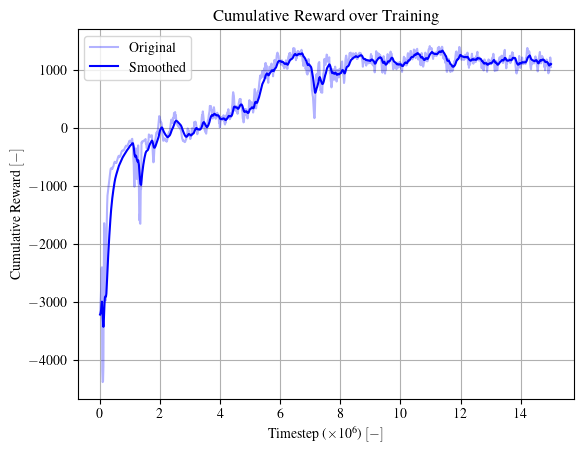

In [5]:
# Define paths (adjust this according to your script location)
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
log_dir = os.path.join(parent_dir, 
                       "results", 
                       "excavator365-RockCapturing",
                       "hp_lr_0.0003-batch_size_128-epochs_4-entropy_coef_0.0003-update_interval_1024-",
                       Training, 
                       "model_log")

csv_path = os.path.join(log_dir, "progress.csv")
figures_dir = os.path.join(log_dir, "figures")
os.makedirs(figures_dir, exist_ok=True)

# Load data
df = pd.read_csv(csv_path)

# Drop NaN in mean return column
df_filtered = df.dropna(subset=['rollout/ep_rew_mean'])

# Use total timesteps if available, else use index
if 'time/total_timesteps' in df_filtered.columns:
    x = df_filtered['time/total_timesteps']
else:
    x = df_filtered.index

y = df_filtered['rollout/ep_rew_mean']

y_smooth = exponential_moving_average(y, smoothing_factor=0.9)

# Plot
plt.figure()
plt.plot(x / 1e6, y, label='Original', color='blue', alpha=0.3 )
plt.plot(x / 1e6, y_smooth, label='Smoothed', color='blue')
plt.xlabel(r'Timestep ($\times 10^6$) $[-]$')
plt.ylabel(r'Cumulative Reward $[-]$')
plt.title(r'Cumulative Reward over Training')
plt.grid(True)
plt.legend()
# plt.ylim([-3.5e3,1.5e3])
# plt.tight_layout()

# Save figures
plt.savefig("cumulative_reward.pdf", format="pdf", bbox_inches="tight")
plt.show()


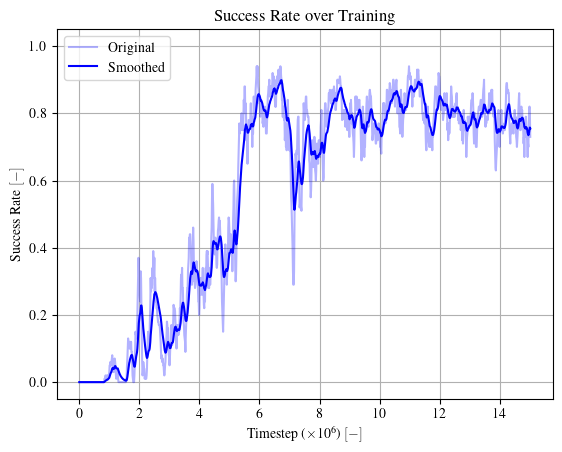

In [6]:
# Define paths (adjust this according to your script location)
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
log_dir = os.path.join(parent_dir, 
                       "results", 
                       "excavator365-RockCapturing",
                       "hp_lr_0.0003-batch_size_128-epochs_4-entropy_coef_0.0003-update_interval_1024-",
                       Training, 
                       "model_log")

csv_path = os.path.join(log_dir, "progress.csv")
figures_dir = os.path.join(log_dir, "figures")
os.makedirs(figures_dir, exist_ok=True)

# Load data
df = pd.read_csv(csv_path)

# Drop NaN in mean return column
df_filtered = df.dropna(subset=['rollout/success_rate'])

# Use total timesteps if available, else use index
if 'time/total_timesteps' in df_filtered.columns:
    x = df_filtered['time/total_timesteps']
else:
    x = df_filtered.index

y = df_filtered['rollout/success_rate']

# Apply smoothing to the mean return
y_smooth = exponential_moving_average(y, smoothing_factor=0.9)

# Plot
plt.figure()
plt.plot(x / 1e6, y, label='Original', color='blue', alpha=0.3)
plt.plot(x / 1e6, y_smooth, label='Smoothed', color='blue')
plt.xlabel(r'Timestep ($\times 10^6$) $[-]$')
plt.ylabel(r'Success Rate $[-]$')
plt.title(r'Success Rate over Training')
plt.grid(True)
plt.ylim([-0.05,1.05])
plt.legend()
# plt.tight_layout()

# Save figures
plt.savefig("success_rate.pdf", format="pdf", bbox_inches="tight")
plt.show()
